# Módulo 2 — Análise NDVI do Sítio com Sentinel-2

O **NDVI** (Normalized Difference Vegetation Index) mede a saúde da vegetação usando imagens de satélite. Quanto mais verde e saudável a planta, mais luz infravermelha ela reflete e mais luz vermelha ela absorve.

**Fórmula:** `NDVI = (NIR - RED) / (NIR + RED)`

**Interpretação:**
| NDVI | Significado |
|------|------------|
| -0.2 a 0.0 | Água, solo exposto, construções |
| 0.0 a 0.2 | Solo com pouca vegetação |
| 0.2 a 0.4 | Vegetação rala (pastagem seca) |
| 0.4 a 0.6 | Vegetação moderada (pastagem verde, cultivo) |
| 0.6 a 0.8 | Vegetação densa e saudável (mata) |
| 0.8 a 1.0 | Vegetação muito densa (floresta tropical) |

**Fonte de dados:** Sentinel-2 (ESA) — resolução de 10m, revisita a cada ~5 dias

In [1]:
import sys
sys.path.append("..")

import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd

from src.ee_utils import (
    inicializar_ee,
    carregar_geometria_sitio,
    coletar_sentinel2,
    composto_mediana,
    extrair_serie_temporal_ndvi,
    obter_estatisticas_ndvi,
    gerar_url_tile_ndvi,
    gerar_url_tile_rgb,
)
from src.config import SITIO_CENTER

# Inicializar Earth Engine
inicializar_ee()
geometria = carregar_geometria_sitio()
print("Earth Engine inicializado e geometria do sítio carregada.")

Earth Engine inicializado e geometria do sítio carregada.


## 1. Coleta de imagens Sentinel-2

Coletamos imagens dos últimos 12 meses com menos de 20% de cobertura de nuvens e criamos um **composto de mediana** — técnica que combina múltiplas imagens eliminando ruído e nuvens residuais.

In [2]:
# Coletar imagens Sentinel-2 dos últimos 12 meses
colecao = coletar_sentinel2(geometria, "2025-04-01", "2026-04-01", max_nuvens=20)
qtd_imagens = colecao.size().getInfo()
print(f"Imagens disponíveis (< 20% nuvens): {qtd_imagens}")

# Criar composto de mediana com índices espectrais
composto = composto_mediana(colecao, geometria)
print("Composto de mediana criado com bandas: NDVI, NDWI, BSI")

# Estatísticas NDVI do sítio
stats = obter_estatisticas_ndvi(composto, geometria)
print(f"\n--- Estatísticas NDVI do Sítio ---")
print(f"Média:         {stats['media']:.3f}")
print(f"Mínimo:        {stats['minimo']:.3f}")
print(f"Máximo:        {stats['maximo']:.3f}")
print(f"Desvio padrão: {stats['desvio_padrao']:.3f}")

Imagens disponíveis (< 20% nuvens): 25
Composto de mediana criado com bandas: NDVI, NDWI, BSI



--- Estatísticas NDVI do Sítio ---
Média:         0.613
Mínimo:        0.091
Máximo:        0.813
Desvio padrão: 0.122


## 2. Mapa NDVI interativo

Mapa do sítio com camadas alternáveis:
- **Satélite Sentinel-2** — imagem real do satélite (10m resolução, muito melhor que Google/Esri)
- **NDVI** — mapa de calor da saúde da vegetação (vermelho = ruim, verde = saudável)
- **Satélite Esri** — referência visual

In [3]:
# Gerar URLs de tile para o mapa
url_ndvi = gerar_url_tile_ndvi(composto)
url_rgb = gerar_url_tile_rgb(composto)

# Carregar polígono do sítio
from src.geo_utils import carregar_sitio
gdf_sitio = carregar_sitio()

# Criar mapa
mapa_ndvi = folium.Map(location=SITIO_CENTER, zoom_start=17, tiles=None)

# Camada base (Esri satélite)
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    name="Satélite (Esri)",
    attr="Esri",
).add_to(mapa_ndvi)

# Camada Sentinel-2 RGB (cor verdadeira do satélite)
folium.TileLayer(
    tiles=url_rgb,
    name="Sentinel-2 (Cor Real)",
    attr="Google Earth Engine / ESA Copernicus",
    overlay=False,
).add_to(mapa_ndvi)

# Camada NDVI
folium.TileLayer(
    tiles=url_ndvi,
    name="NDVI (Saúde da Vegetação)",
    attr="Google Earth Engine / ESA Copernicus",
    overlay=False,
).add_to(mapa_ndvi)

# Contorno do sítio
folium.GeoJson(
    gdf_sitio.to_json(),
    name="Limite do Sítio",
    style_function=lambda x: {
        "fillColor": "transparent",
        "color": "#FFD700",
        "weight": 3,
        "fillOpacity": 0,
    },
).add_to(mapa_ndvi)

# Marcador com estatísticas
folium.CircleMarker(
    location=SITIO_CENTER,
    radius=8,
    color="#FFD700",
    fill=True,
    fill_color="#228B22",
    fill_opacity=0.8,
    popup=(
        f"<b>NDVI do Sítio</b><br>"
        f"Média: {stats['media']:.3f}<br>"
        f"Mín: {stats['minimo']:.3f} | Máx: {stats['maximo']:.3f}<br>"
        f"Desvio: {stats['desvio_padrao']:.3f}"
    ),
).add_to(mapa_ndvi)

folium.LayerControl().add_to(mapa_ndvi)
mapa_ndvi

## 3. Série temporal — Evolução da vegetação

Extraímos o NDVI médio do sítio para cada imagem Sentinel-2 dos últimos 3 anos. Isso mostra:
- **Sazonalidade** — vegetação mais verde no verão (chuvas), mais seca no inverno
- **Tendências** — se a vegetação está melhorando ou degradando ao longo dos anos
- **Anomalias** — quedas bruscas podem indicar desmatamento, queimada ou seca severa

In [4]:
# Extrair série temporal NDVI dos últimos 3 anos
print("Extraindo série temporal NDVI (2023-2026)... pode levar ~1 minuto")
df_ndvi = extrair_serie_temporal_ndvi(geometria, "2023-04-01", "2026-04-09", max_nuvens=30)
print(f"Total de observações: {len(df_ndvi)}")
print(f"Período: {df_ndvi['data'].min().strftime('%d/%m/%Y')} a {df_ndvi['data'].max().strftime('%d/%m/%Y')}")
print(f"NDVI médio geral: {df_ndvi['ndvi_medio'].mean():.3f}")
df_ndvi.head(10)

Extraindo série temporal NDVI (2023-2026)... pode levar ~1 minuto


Total de observações: 107
Período: 01/04/2023 a 05/04/2026
NDVI médio geral: 0.555


,data,ndvi_medio
0,2023-04-01 13:18:37.628,0.739298
1,2023-04-11 13:18:38.982,0.711115
2,2023-04-16 13:18:40.121,0.723769
3,2023-04-21 13:18:37.458,0.723594
4,2023-05-16 13:18:43.132,0.687628
5,2023-05-26 13:18:43.502,0.630207
6,2023-06-05 13:18:40.475,0.617418
7,2023-06-10 13:18:42.709,0.592441
8,2023-06-20 13:18:42.733,0.573877
9,2023-06-25 13:18:43.288,0.578059


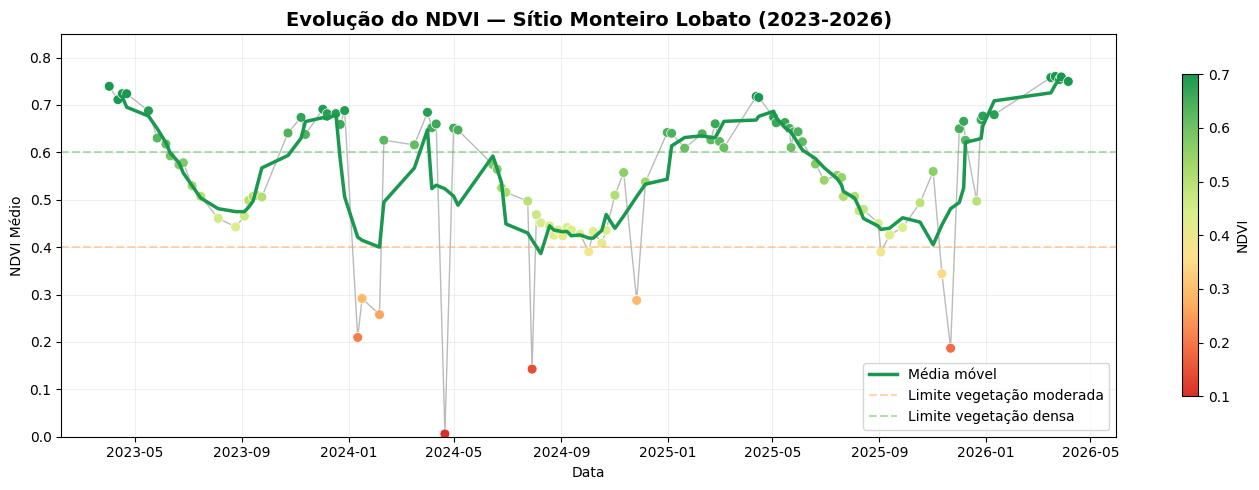

Gráfico salvo em data/ndvi_serie_temporal.png


In [5]:
# Gráfico da série temporal NDVI
fig, ax = plt.subplots(figsize=(14, 5))

# Colorir pontos pelo valor do NDVI
cores_ndvi = ["#d73027", "#f46d43", "#fdae61", "#fee08b", "#d9ef8b", "#a6d96a", "#66bd63", "#1a9850"]
cmap = mcolors.LinearSegmentedColormap.from_list("ndvi", cores_ndvi)
norm = mcolors.Normalize(vmin=0.1, vmax=0.7)

# Linha de tendência
ax.plot(df_ndvi["data"], df_ndvi["ndvi_medio"], color="#555555", alpha=0.4, linewidth=1, zorder=1)

# Pontos coloridos
scatter = ax.scatter(
    df_ndvi["data"], df_ndvi["ndvi_medio"],
    c=df_ndvi["ndvi_medio"], cmap=cmap, norm=norm,
    s=50, edgecolors="white", linewidth=0.5, zorder=2,
)

# Média móvel (30 dias)
df_ndvi["media_movel"] = df_ndvi["ndvi_medio"].rolling(window=5, center=True).mean()
ax.plot(df_ndvi["data"], df_ndvi["media_movel"], color="#1a9850", linewidth=2.5, label="Média móvel", zorder=3)

# Referências
ax.axhline(y=0.4, color="#fdae61", linestyle="--", alpha=0.5, label="Limite vegetação moderada")
ax.axhline(y=0.6, color="#66bd63", linestyle="--", alpha=0.5, label="Limite vegetação densa")

ax.set_title("Evolução do NDVI — Sítio Monteiro Lobato (2023-2026)", fontsize=14, fontweight="bold")
ax.set_xlabel("Data")
ax.set_ylabel("NDVI Médio")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.2)
ax.set_ylim(0, 0.85)

plt.colorbar(scatter, ax=ax, label="NDVI", shrink=0.8)
plt.tight_layout()
plt.savefig("../data/ndvi_serie_temporal.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo em data/ndvi_serie_temporal.png")

## 4. Análise sazonal — NDVI por mês

Agrupamos o NDVI por mês para entender o ciclo da vegetação no sítio ao longo do ano.

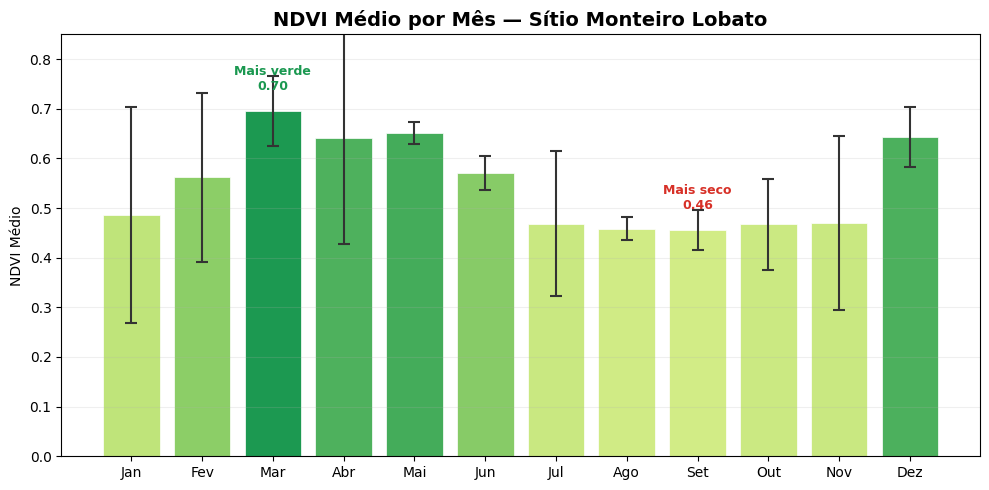

In [6]:
# Análise sazonal
df_ndvi["mes"] = df_ndvi["data"].dt.month
meses_nomes = {1:"Jan", 2:"Fev", 3:"Mar", 4:"Abr", 5:"Mai", 6:"Jun",
               7:"Jul", 8:"Ago", 9:"Set", 10:"Out", 11:"Nov", 12:"Dez"}
df_ndvi["mes_nome"] = df_ndvi["mes"].map(meses_nomes)

sazonal = df_ndvi.groupby("mes")["ndvi_medio"].agg(["mean", "std", "count"]).reset_index()
sazonal["mes_nome"] = sazonal["mes"].map(meses_nomes)

fig, ax = plt.subplots(figsize=(10, 5))

cores_mes = [cmap(norm(v)) for v in sazonal["mean"]]
bars = ax.bar(sazonal["mes_nome"], sazonal["mean"], color=cores_mes, edgecolor="white", linewidth=0.5)
ax.errorbar(sazonal["mes_nome"], sazonal["mean"], yerr=sazonal["std"],
            fmt="none", color="#333333", capsize=4, capthick=1.5)

ax.set_title("NDVI Médio por Mês — Sítio Monteiro Lobato", fontsize=14, fontweight="bold")
ax.set_ylabel("NDVI Médio")
ax.set_ylim(0, 0.85)
ax.grid(True, alpha=0.2, axis="y")

# Anotar meses mais verde e mais seco
mes_max = sazonal.loc[sazonal["mean"].idxmax()]
mes_min = sazonal.loc[sazonal["mean"].idxmin()]
ax.annotate(f"Mais verde\n{mes_max['mean']:.2f}", xy=(mes_max["mes"]-1, mes_max["mean"]),
            xytext=(0, 15), textcoords="offset points", ha="center", fontsize=9, color="#1a9850", fontweight="bold")
ax.annotate(f"Mais seco\n{mes_min['mean']:.2f}", xy=(mes_min["mes"]-1, mes_min["mean"]),
            xytext=(0, 15), textcoords="offset points", ha="center", fontsize=9, color="#d73027", fontweight="bold")

plt.tight_layout()
plt.savefig("../data/ndvi_sazonal.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Exportar mapa NDVI interativo

Salvamos o mapa com as camadas de satélite real e NDVI como HTML.

In [7]:
# Salvar mapa NDVI
mapa_ndvi.save("../data/mapa_ndvi.html")
print("Mapa NDVI salvo em data/mapa_ndvi.html")

# Salvar série temporal como CSV
df_ndvi.to_csv("../data/ndvi_serie_temporal.csv", index=False)
print("Série temporal salva em data/ndvi_serie_temporal.csv")

Mapa NDVI salvo em data/mapa_ndvi.html
Série temporal salva em data/ndvi_serie_temporal.csv
